In [1]:
import numpy as np
from collections import deque
import torch
import torch.optim as optim
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
class PegSolitaire:
    def __init__(self):
        self.board_layout = np.array([
            [-1, -1,  1,  1,  1, -1, -1],
            [-1, -1,  1,  1,  1, -1, -1],
            [ 1,  1,  1,  1,  1,  1,  1],
            [ 1,  1,  1,  0,  1,  1,  1],
            [ 1,  1,  1,  1,  1,  1,  1],
            [-1, -1,  1,  1,  1, -1, -1],
            [-1, -1,  1,  1,  1, -1, -1]
        ]).flatten()
        
        self.actions = np.where(self.board_layout != -1)[0]  # index list of legal actions
        self.moves = self.get_moves()  # list of action space
        self.reset(0, 1)

    def get_moves(self):
        moves = []
        directions = [(-2, 0), (2, 0), (0, -2), (0, 2)]
        for f in range(49):
            if self.board_layout[f] == -1: continue
                
            x, y = divmod(f, 7)
            for dx, dy in directions:
                tx, ty = x + dx, y + dy
                if 0 <= tx < 7 and 0 <= ty < 7:
                    t = tx * 7 + ty
                    if self.board_layout[t] != -1:
                        m = (x + dx//2) * 7 + y + dy//2
                        moves.append([f, m, t])
        return np.array(moves, dtype=np.int8)

    def get_mask(self):
        b = self.board
        return (b[self.moves[:, 0]] == 1) & (b[self.moves[:, 1]] == 1) & (b[self.moves[:, 2]] == 0)

    def step(self, action):
        self.board[self.moves[action]] = [0, 0, 1]
        self.remain -= 1

        mask = self.get_mask()
        self.done = not np.any(mask)

        reward = 1.0
        if self.done:
            if self.remain == 1 and self.board[24] == 1:
                reward = 100.0
            else:
                reward = -5.0 * self.remain

        return self.board.copy(), reward, self.done, mask

    def reset(self, steps, mode):
        if mode == 0:
            while True:
                self.board = np.full(49, -1, dtype=np.int8)
                for idx in self.actions: self.board[idx] = 0
                self.board[24] = 1 
                
                actual_steps = 0
                for _ in range(steps):
                    b = self.board
                    rev_mask = (b[self.moves[:, 0]] == 0) & (b[self.moves[:, 1]] == 0) & (b[self.moves[:, 2]] == 1)
                    possible = np.where(rev_mask)[0]
                    if len(possible) == 0: break 
                    idx = np.random.choice(possible)
                    self.board[self.moves[idx, [0, 1, 2]]] = [1, 1, 0]
                    actual_steps += 1
                    
                if actual_steps == steps: 
                    break
        else:
            while True:
                self.board = self.board_layout.copy()
                
                actual_steps = 0
                for _ in range(steps):
                    mask = self.get_mask()
                    actions = np.where(mask)[0]
                    if len(actions) == 0: 
                        break
                    idx = np.random.choice(actions)
                    self.board[self.moves[idx]] = [0, 0, 1]
                    actual_steps += 1
                
                if actual_steps == steps:
                    break

        self.remain = np.sum(self.board == 1)
        self.done = False
        return self.board.copy()
    

In [4]:
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)
        self.data = np.zeros(capacity, dtype=object)
        self.n_entries = 0
        self.write = 0

    def add(self, p, data):
        idx = self.write + self.capacity - 1
        self.data[self.write] = data
        self.update(idx, p)
        self.write = (self.write + 1) % self.capacity
        if self.n_entries < self.capacity: self.n_entries += 1

    def update(self, idx, p):
        change = p - self.tree[idx]
        self.tree[idx] = p
        while idx != 0:
            idx = (idx - 1) // 2
            self.tree[idx] += change

    def get_leaf(self, v):
        parent_idx = 0
        while True:
            left_child_idx = 2 * parent_idx + 1
            right_child_idx = left_child_idx + 1
            if left_child_idx >= len(self.tree):
                leaf_idx = parent_idx
                break
            if v <= self.tree[left_child_idx]:
                parent_idx = left_child_idx
            else:
                v -= self.tree[left_child_idx]
                parent_idx = right_child_idx
        return leaf_idx, self.tree[leaf_idx], self.data[leaf_idx - self.capacity + 1]

    @property
    def total_priority(self):
        return self.tree[0]

In [5]:
class Agent:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.episodes = 100000
        self.gamma = 0.99
        self.lr = 5e-5
        self.lr_min = 1e-5
        self.batch_size = 256
        self.eps = 1.0
        self.eps_min = 0.01
        self.subtrahend = (self.eps - self.eps_min) / (self.episodes * 0.8)
        self.tau = 0.005
        self.max_norm = 1.0

        self.memory = SumTree(100000)
        self.alpha = 0.6
        self.beta = 0.4
        self.beta_increment = (1.0 - self.beta) / (self.episodes * 0.9)
        self.abs_err_upper = 1.0

        self.q_network = DQN().to(self.device)
        self.target_network = DQN().to(self.device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.optimizer = optim.AdamW(self.q_network.parameters(), lr=self.lr)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=self.episodes, eta_min=self.lr_min)

        self.q_history = deque(maxlen=1000)

    def update_eps(self):
        if self.eps > self.eps_min:
            self.eps = max(self.eps_min, self.eps - self.subtrahend)

    def act(self, state, mask):
        if np.random.random() <= self.eps:
            actions = np.where(mask)[0]
            return np.random.choice(actions)

        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q_values = self.q_network(state_t)
            mask_t = torch.BoolTensor(mask).to(self.device).unsqueeze(0)
            q_values[~mask_t] = float('-inf')
            action = q_values.argmax(dim=1).item()  # choose the optimal action's index

            self.q_history.append(q_values[0, action].item())

            return action

    def replay(self):
        if self.memory.n_entries < self.batch_size: return 0.0

        indices = []
        batch = []
        priorities = []
        segment = self.memory.total_priority / self.batch_size
        self.beta = min(1.0, self.beta + self.beta_increment)

        for i in range(self.batch_size):
            a = segment * i
            b = segment * (i + 1)
            v = np.random.uniform(a, b)
            idx, p, data = self.memory.get_leaf(v)
            priorities.append(p)
            indices.append(idx)
            batch.append(data)

        sampling_probabilities = np.array(priorities) / self.memory.total_priority
        is_weights = np.power(self.memory.n_entries * sampling_probabilities, -self.beta)
        is_weights /= is_weights.max()
        is_weights_t = torch.FloatTensor(is_weights).to(self.device)

        states = torch.tensor(np.array([e[0] for e in batch]), dtype=torch.float32, device=self.device)
        actions = torch.tensor([e[1] for e in batch], dtype=torch.long, device=self.device).unsqueeze(1)
        rewards = torch.tensor([e[2] for e in batch], dtype=torch.float32, device=self.device)
        next_states = torch.tensor(np.array([e[3] for e in batch]), dtype=torch.float32, device=self.device)
        dones = torch.tensor([e[4] for e in batch], dtype=torch.bool, device=self.device)
        next_masks = torch.tensor(np.array([e[5] for e in batch]), dtype=torch.bool, device=self.device)

        q_values = self.q_network(states)
        q_current = q_values.gather(1, actions).squeeze(1)

        with torch.no_grad():
            next_q_online = self.q_network(next_states)
            next_q_online[~next_masks] = float('-inf')
            next_actions = next_q_online.argmax(dim=1, keepdim=True)
            next_q_target = self.target_network(next_states)
            q_next = next_q_target.gather(1, next_actions).squeeze(1)
            q_next[~next_masks.any(dim=1)] = 0.0
            q_target = rewards + (self.gamma * q_next * (~dones).float())

        td_errors = torch.abs(q_current - q_target).detach().cpu().numpy()
        for i in range(self.batch_size):
            new_p = np.power(td_errors[i] + 1e-5, self.alpha)
            self.memory.update(indices[i], new_p)

        loss = (is_weights_t * F.smooth_l1_loss(q_current, q_target, reduction='none')).mean()

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), max_norm=self.max_norm)
        self.optimizer.step()

        for target_param, param in zip(self.target_network.parameters(), self.q_network.parameters()):
            target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)

        return loss.item()

In [6]:
class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_layer = nn.Sequential(
            nn.Unflatten(1, (1, 7, 7)),
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU()
        )
        self.value_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 76)
        )

    def forward(self, x):
        features = self.feature_layer(x)
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        return value + advantage - advantage.mean(dim=-1, keepdim=True)

In [ ]:
def draw(eps, rems, sts, lss):
    _, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    axs[0].plot(eps, rems, color='tab:red', linewidth=1)
    axs[0].set_ylabel('Remain')
    axs[0].grid(True, linestyle='--', alpha=0.6)

    axs[1].plot(eps, sts, color='tab:blue', linewidth=1)
    axs[1].set_ylabel('Step')
    axs[1].grid(True, linestyle='--', alpha=0.6)

    axs[2].plot(eps, lss, color='tab:green', linewidth=1)
    axs[2].set_ylabel('Loss')
    axs[2].set_xlabel('Episode')
    axs[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig('train_curve.png') 
    plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Episode    100  |  Step  1.9  |  Score   20.6  |  Loss   nan  |  Eps  1.00  |  Q   nan  |  Rem 1.56
Episode    200  |  Step  2.0  |  Score   23.5  |  Loss 20.848  |  Eps  1.00  |  Q   nan  |  Rem 1.55
Episode    300  |  Step  1.8  |  Score   31.8  |  Loss 13.120  |  Eps  1.00  |  Q   nan  |  Rem 1.53
Episode    400  |  Step  1.9  |  Score   19.7  |  Loss 5.109  |  Eps  1.00  |  Q  41.1  |  Rem 1.47
Episode    500  |  Step  2.0  |  Score   14.6  |  Loss 5.041  |  Eps  0.99  |  Q  55.5  |  Rem 1.64
Episode    600  |  Step  2.1  |  Score   21.7  |  Loss 4.555  |  Eps  0.99  |  Q  56.4  |  Rem 1.63
Episode    700  |  Step  1.8  |  Score   28.2  |  Loss 4.479  |  Eps  0.99  |  Q  72.2  |  Rem 1.44
Episode    800  |  Step  1.9  |  Score   30.5  |  Loss 4.686  |  Eps  0.99  |  Q  72.2  |  Rem 1.53
Episode    900  |  Step  2.1  |  Score   27.2  |  Loss 5.289  |  Eps  0.99  |  Q  77.1  |  Rem 1.65
Episode   1000  |  Step  2.0  |  Score   15.5  |  Loss 6.158  |  Eps  0.99  |  Q  77.1  |  Rem 1.7

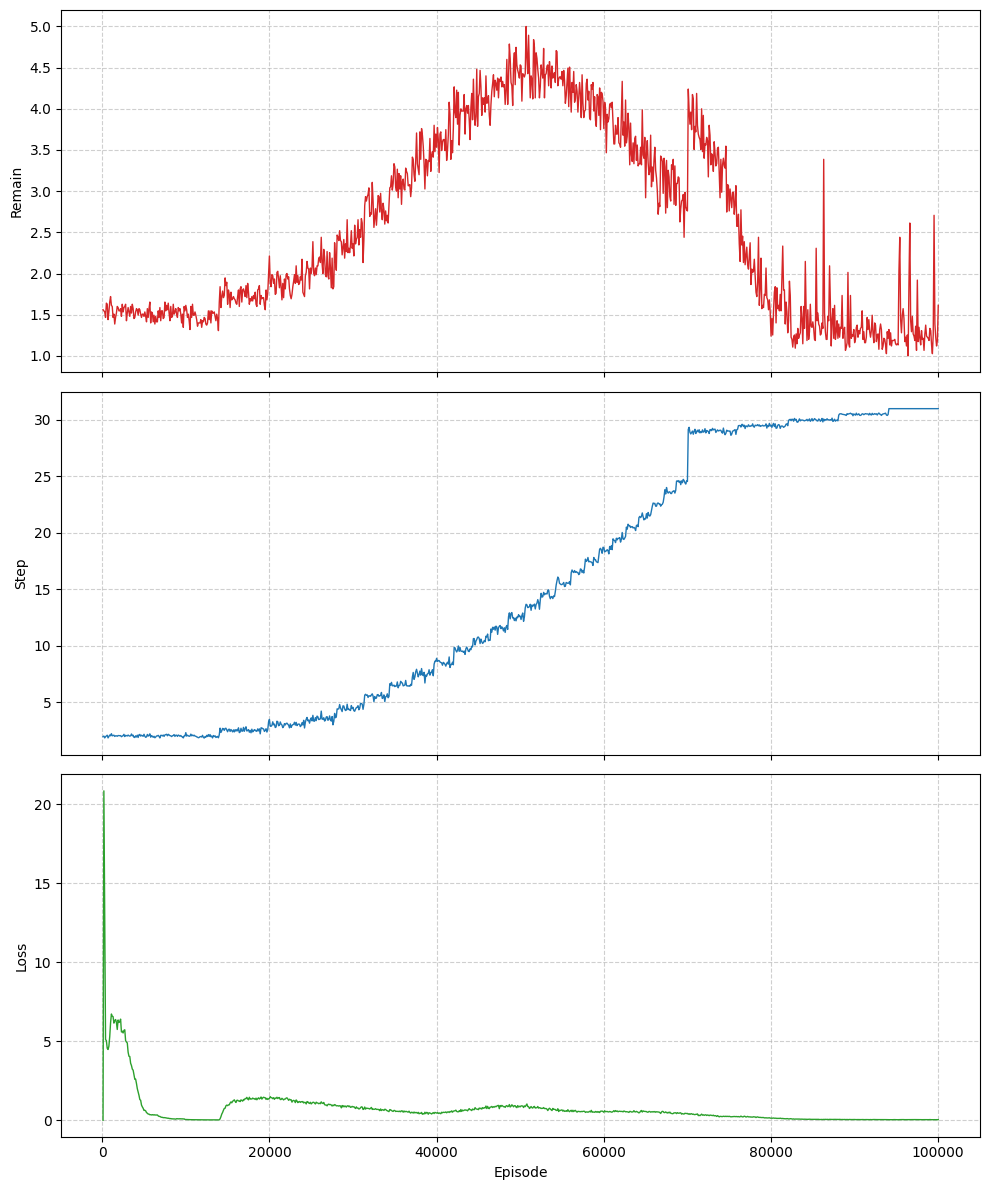

In [ ]:
set_seed(0)

env = PegSolitaire()
agent = Agent()

steps = deque(maxlen=75)
scores = deque(maxlen=75)
losses = deque(maxlen=75)
remains = deque(maxlen=75)
least_rem = 1.5

history_remains = []
history_steps = []
history_losses = []
history_episodes = []

for episode in range(1, agent.episodes + 1):
    progress = episode / agent.episodes
    percent = 0.7
    if progress < percent:
        mode = 0
        max_step = int(3 + 25 * ( (progress / percent) ** 2 ) )
        curr_step = np.random.randint(max(1, max_step - 5), max_step + 1)
        step = curr_step
    else:
        mode = 1
        max_step = int(5 * (1 - (progress - percent) / (1 - percent) ) )
        curr_step = np.random.randint(0, max_step + 1)
        step = 31 - curr_step

    state = env.reset(curr_step, mode)
    mask = env.get_mask()

    total_reward = 0
    done = False
    
    while not done:
        if not np.any(mask): break

        action = agent.act(state, mask)
        next_state, reward, done, next_mask = env.step(action)

        max_p = np.power(agent.abs_err_upper, agent.alpha)
        agent.memory.add(max_p, (state, action, reward, next_state, done, next_mask))

        if agent.memory.n_entries > agent.batch_size:
            loss = agent.replay()
            if loss > 0:
                losses.append(loss)

        state = next_state
        mask = next_mask
        total_reward += reward

    agent.update_eps()  

    if len(losses) > 0:
        agent.scheduler.step()

    scores.append(total_reward)
    remains.append(env.remain)
    steps.append(step)

    if (episode % 100 == 0): 
        print(f"Episode {episode:6d}  |  Step {np.mean(steps):4.1f}  |  Score {np.mean(scores):6.1f}  |  Loss {np.mean(losses):5.3f}"
            f"  |  Eps {agent.eps:5.2f}  |  Q {np.mean(agent.q_history):5.1f}  |  Rem {np.mean(remains):4.2f}")
        
        history_episodes.append(episode)
        history_remains.append(np.mean(remains))
        history_steps.append(np.mean(steps))
        history_losses.append(np.mean(losses) if len(losses) > 0 else 0)

        if np.mean(steps) > 30.0: 
            if np.mean(remains) < least_rem:
                save_episode = episode
                least_rem = np.mean(remains)
                torch.save(agent.q_network.state_dict(), 'model.pth')
            
print(f"Least Rem {least_rem:.2f}  ( Episode {save_episode} )")

draw(history_episodes, history_remains, history_steps, history_losses)

In [9]:
class TestAgent:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
        self.q_network = DQN().to(self.device)
        self.q_network.load_state_dict(torch.load('/kaggle/working/model.pth', map_location=self.device))
        self.q_network.eval() 
    def act(self, state, mask):
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
            q_values = self.q_network(state_t).cpu().numpy()[0]
            
            actions = np.where(mask)[0]
            if len(actions) == 0:
                return None, 0

            best_idx = np.argmax(q_values[actions])
            action = actions[best_idx]
            
            sorted_q = np.sort(q_values)[::-1]
            chosen_q = q_values[action]
            rank = np.where(sorted_q == chosen_q)[0][0]
            
            return action, rank

In [10]:
def test(step, mode):
    wins = 0
    episodes = 1000
    remains = []
    q_ranks = []
        
    for _ in range(episodes):
        state = env.reset(step, mode)
        mask = env.get_mask()
            
        game_ranks = []
            
        while not env.done:
            action, rank = agent.act(state, mask)
            game_ranks.append(rank)
                
            state, _, _, mask = env.step(action)

        if env.remain == 1 and env.board[24] == 1: 
            wins += 1
        remains.append(env.remain)
        if len(game_ranks) > 0:
            q_ranks.append(np.mean(game_ranks))
            
    if mode == 1:
        step = 31 - step
        
    print(f'Step {step:<3}  |  Win {wins/episodes:<6.1%}  |  Remain {np.mean(remains):<5.2f}  |  Q Rank {np.mean(q_ranks):.1f}')

In [11]:
agent = TestAgent()

print('Reverse Test')
for step in range(1, 30):
    test(step, 0)

print('Forward Test')
for step in range(1, 20):
    test(step, 1)

Reverse Test
Step 1    |  Win 100.0%  |  Remain 1.00   |  Q Rank 23.0
Step 2    |  Win 100.0%  |  Remain 1.00   |  Q Rank 22.0
Step 3    |  Win 100.0%  |  Remain 1.00   |  Q Rank 19.5
Step 4    |  Win 99.5%   |  Remain 1.01   |  Q Rank 18.6
Step 5    |  Win 95.5%   |  Remain 1.09   |  Q Rank 18.7
Step 6    |  Win 91.9%   |  Remain 1.17   |  Q Rank 18.4
Step 7    |  Win 87.4%   |  Remain 1.30   |  Q Rank 18.2
Step 8    |  Win 83.1%   |  Remain 1.42   |  Q Rank 18.2
Step 9    |  Win 76.4%   |  Remain 1.67   |  Q Rank 17.7
Step 10   |  Win 75.1%   |  Remain 1.67   |  Q Rank 17.6
Step 11   |  Win 72.5%   |  Remain 1.77   |  Q Rank 17.0
Step 12   |  Win 71.3%   |  Remain 1.81   |  Q Rank 16.8
Step 13   |  Win 68.9%   |  Remain 1.89   |  Q Rank 16.6
Step 14   |  Win 68.3%   |  Remain 1.95   |  Q Rank 16.3
Step 15   |  Win 65.4%   |  Remain 2.04   |  Q Rank 16.3
Step 16   |  Win 65.9%   |  Remain 2.00   |  Q Rank 16.0
Step 17   |  Win 66.1%   |  Remain 2.00   |  Q Rank 15.8
Step 18   |  Win 6